# Telco Customer Churn Analysis & Prediction

# Telco Customer Churn Analysis

## Project Overview

Customer churn is an important business challenge for telecommunications companies because losing existing customers can affect revenue, customer lifetime value, and long-term business growth.

This project analyzes customer-level telecommunications data to identify patterns associated with customer churn and develops machine learning models to predict customers who may be at risk of leaving the company.

The project combines exploratory data analysis, statistical examination, machine learning, model evaluation, model interpretation, and business recommendations.

The analysis focuses on understanding which customer characteristics and service-related factors are associated with churn and how predictive modeling can support customer-retention decisions.

---

## Business Problem

The telecommunications company wants to better understand why customers leave and identify customers who may be at higher risk of churn.

The key business questions are:

1. What customer characteristics are associated with churn?
2. Which contract and service categories show higher observed churn rates?
3. Does customer tenure relate to churn?
4. Which features provide the strongest predictive information for churn?
5. How well can machine learning models identify customers who are likely to churn?
6. How does changing the classification threshold affect precision and recall?
7. How can the analytical findings support customer-retention strategies?

---

## Project Objectives

The objectives of this project are to:

* Inspect and clean the customer churn dataset.
* Explore patterns and relationships associated with customer churn.
* Perform univariate, bivariate, and multivariate analysis.
* Prepare customer data for machine learning.
* Develop and compare multiple classification models.
* Evaluate model performance using appropriate classification metrics.
* Assess model overfitting and cross-validation stability.
* Examine the effect of different classification thresholds.
* Interpret important model features.
* Translate analytical findings into practical business insights and recommendations.

---

## Analytical Approach

The project follows an end-to-end data analytics and machine learning workflow:

**Business Problem → Data Inspection → Data Cleaning → Exploratory Data Analysis → Feature Preparation → Preprocessing → Model Development → Model Evaluation → Model Interpretation → Business Insights → Recommendations**

---

## Dataset

The analysis uses the Telco Customer Churn dataset, containing customer demographic, account, service, billing, tenure, and churn information.

The target variable is:

**Churn**

* `No` = customer did not churn
* `Yes` = customer churned

For machine learning, the target was encoded as:

* `0` = No churn
* `1` = Churn


In [1]:
# ============================================
# Libraries and Tools
# ============================================

import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Data splitting and cross-validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

# Preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.inspection import permutation_importance

# XGBoost
from xgboost import XGBClassifier

In [2]:
project_folder = r"C:\Users\user\Telco-Customer-Churn-Analysis"

images_folder = os.path.join(project_folder, "images")
data_folder = os.path.join(project_folder, "data")
notebooks_folder = os.path.join(project_folder, "notebooks")

print("Project folder:", project_folder)
print("Images folder:", images_folder)
print("Data folder:", data_folder)

Project folder: C:\Users\user\Telco-Customer-Churn-Analysis
Images folder: C:\Users\user\Telco-Customer-Churn-Analysis\images
Data folder: C:\Users\user\Telco-Customer-Churn-Analysis\data


# Load & Inspect Dataset

In [3]:
df = pd.read_csv(
    os.path.join(data_folder, "Telco-Customer-Churn.csv")
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID      

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.describe(include="str")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Data Cleaning

In [8]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values created during conversion
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

# Replace missing TotalCharges values
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Remaining missing values:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 11
TotalCharges dtype: float64
Remaining missing values: 0


In [9]:
print(
    df.loc[
        df["tenure"] == 0,
        ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)

      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           0.0    No
753        0           20.25           0.0    No
936        0           80.85           0.0    No
1082       0           25.75           0.0    No
1340       0           56.05           0.0    No
3331       0           19.85           0.0    No
3826       0           25.35           0.0    No
4380       0           20.00           0.0    No
5218       0           19.70           0.0    No
6670       0           73.35           0.0    No
6754       0           61.90           0.0    No


The `TotalCharges` column was stored as a text field and contained blank values. These values correspond to customers with zero tenure.

The column was converted to numeric format, with invalid/blank values coerced to missing values and then replaced with 0.

#  Exploratory Data Analysis

# Univariate EDA

##  Churn Distribution

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


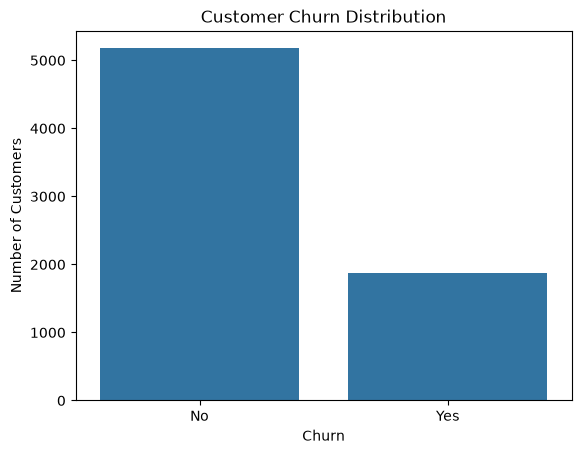

In [10]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate.round(2))

sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

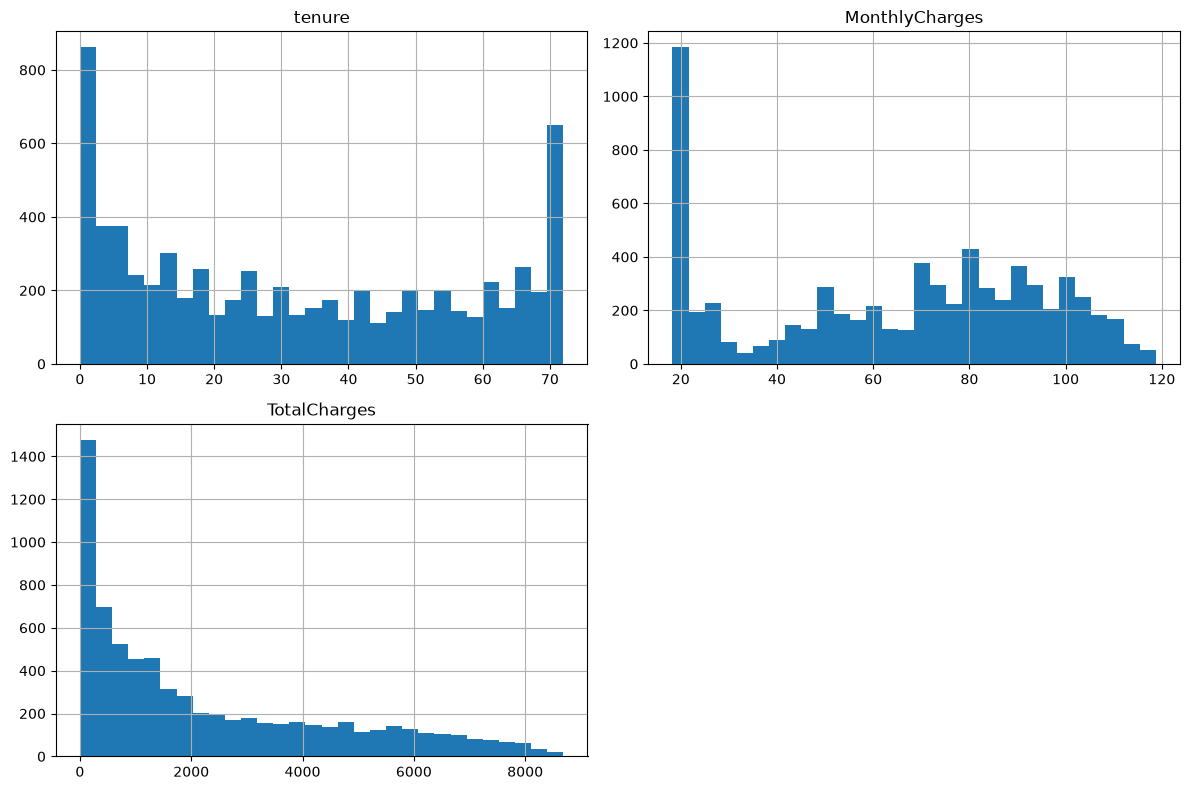

In [11]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

### Overall Churn Distribution

Customer churn is examined first to understand the overall distribution of retained and churned customers.

# Bivariate EDA

## Churn by Gender

In [12]:
gender_churn = (pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100)
print(gender_churn.round(2))

Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16


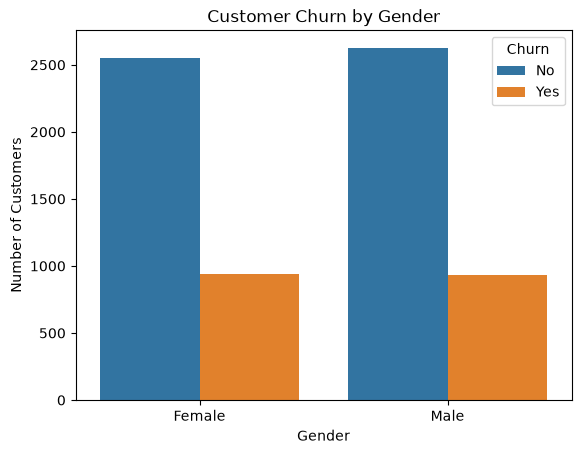

In [13]:
sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

## 9.3 Churn by Contract Type

In [14]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


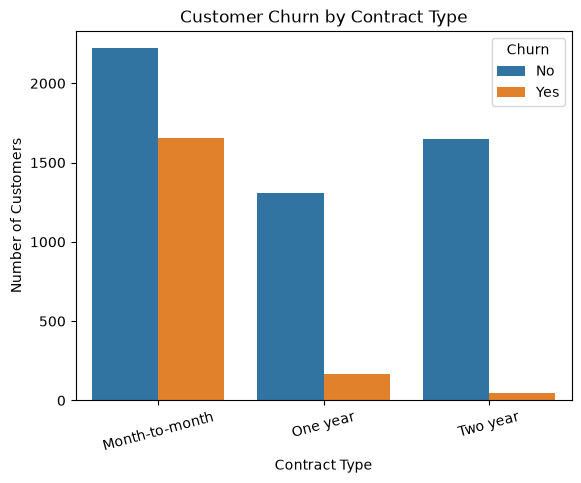

In [15]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

### Churn by Contract Type

Churn rates are compared across contract types to identify differences in retention patterns.

## 9.4 Churn by Tenure

In [16]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0–6 months",
        "7–12 months",
        "13–24 months",
        "25–48 months",
        "49–72 months"
    ]
)
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn.round(2)

Churn,No,Yes
TenureGroup,,
0–6 months,47.06,52.94
7–12 months,64.11,35.89
13–24 months,71.29,28.71
25–48 months,79.61,20.39
49–72 months,90.49,9.51


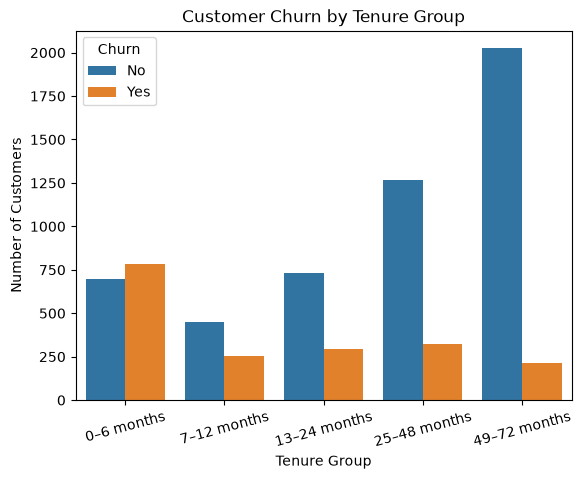

In [17]:
sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

### Note

`TenureGroup` is a derived feature created for exploratory analysis and visualization. It is not used as a machine-learning feature because the original numerical `tenure` variable is retained for modeling.

## 9.5  Churn by Payment Method

In [18]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


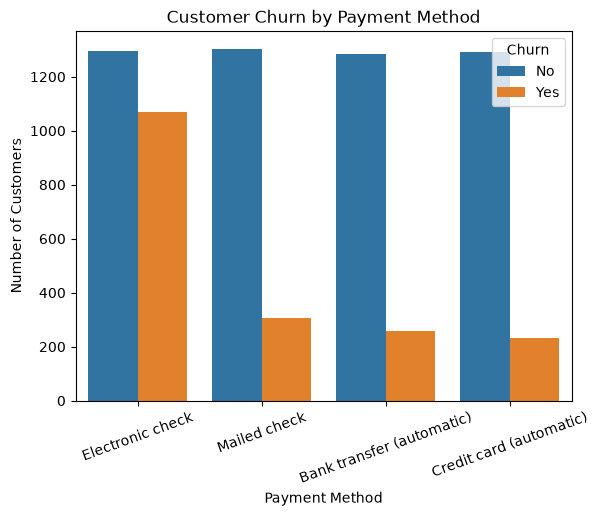

In [19]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

### Churn by Internet Server

In [20]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


# Churn by Monthly Charges

In [21]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "min", "max"]
)

monthly_charges_churn.round(2)

,mean,median,min,max
Churn,,,,
No,61.27,64.43,18.25,118.75
Yes,74.44,79.65,18.85,118.35


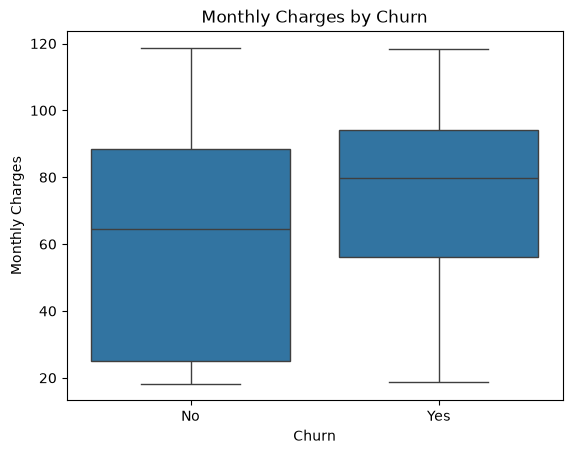

In [22]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

# Churn by Total Charges

In [23]:
total_charges_churn = df.groupby("Churn")["TotalCharges"].agg(
    ["mean", "median", "min", "max"]
)

total_charges_churn.round(2)

,mean,median,min,max
Churn,,,,
No,2549.91,1679.52,0.00,8672.45
Yes,1531.80,703.55,18.85,8684.80


# Churn by Senior Citizens

In [24]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn.round(2)

Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


# Churn by Customers with Partners

In [25]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn.round(2)

Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


# Churn by Customers with Dependents

In [26]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn.round(2)

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


# Multivariate EDA

In [27]:
tenure_contract_churn = pd.crosstab(
    [df["Contract"], df["TenureGroup"]],
    df["Churn"],
    normalize="index"
) * 100

tenure_contract_churn.round(2)

Churn                            No    Yes
Contract       TenureGroup                
Month-to-month 0–6 months     44.80  55.20
               7–12 months    58.00  42.00
               13–24 months   62.28  37.72
               25–48 months   67.08  32.92
               49–72 months   73.98  26.02
One year       0–6 months     89.74  10.26
               7–12 months    89.41  10.59
               13–24 months   91.88   8.12
               25–48 months   89.38  10.62
               49–72 months   87.07  12.93
Two year       0–6 months    100.00   0.00
               7–12 months   100.00   0.00
               13–24 months  100.00   0.00
               25–48 months   97.81   2.19
               49–72 months   96.67   3.33

In [28]:
contract_internet_churn = pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
) * 100

contract_internet_churn.round(2)

Churn                              No    Yes
Contract       InternetService              
Month-to-month DSL              67.78  32.22
               Fiber optic      45.39  54.61
               No               81.11  18.89
One year       DSL              90.70   9.30
               Fiber optic      80.71  19.29
               No               97.53   2.47
Two year       DSL              98.09   1.91
               Fiber optic      92.77   7.23
               No               99.22   0.78

In [29]:
internet_payment_churn = pd.crosstab(
    [df["InternetService"], df["PaymentMethod"]],
    df["Churn"],
    normalize="index"
) * 100

internet_payment_churn.round(2)

Churn                                         No    Yes
InternetService PaymentMethod                          
DSL             Bank transfer (automatic)  90.64   9.36
                Credit card (automatic)    87.88  12.12
                Electronic check           68.06  31.94
                Mailed check               79.28  20.72
Fiber optic     Bank transfer (automatic)  71.05  28.95
                Credit card (automatic)    74.71  25.29
                Electronic check           46.77  53.23
                Mailed check               57.36  42.64
No              Bank transfer (automatic)  94.58   5.42
                Credit card (automatic)    97.28   2.72
                Electronic check           87.70  12.30
                Mailed check               90.42   9.58

In [30]:
contract_support_churn = pd.crosstab(
    [df["Contract"], df["TechSupport"]],
    df["Churn"],
    normalize="index"
) * 100

contract_support_churn.round(2)

Churn                                  No    Yes
Contract       TechSupport                      
Month-to-month No                   49.63  50.37
               No internet service  81.11  18.89
               Yes                  69.30  30.70
One year       No                   85.28  14.72
               No internet service  97.53   2.47
               Yes                  86.41  13.59
Two year       No                   94.07   5.93
               No internet service  99.22   0.78
               Yes                  96.47   3.53

In [31]:
contract_security_churn = pd.crosstab(
    [df["Contract"], df["OnlineSecurity"]],
    df["Churn"],
    normalize="index"
) * 100

contract_security_churn.round(2)

Churn                                  No    Yes
Contract       OnlineSecurity                   
Month-to-month No                   48.95  51.05
               No internet service  81.11  18.89
               Yes                  70.42  29.58
One year       No                   82.59  17.41
               No internet service  97.53   2.47
               Yes                  89.13  10.87
Two year       No                   93.23   6.77
               No internet service  99.22   0.78
               Yes                  97.05   2.95

## Feature Preparation

The target variable is separated from the predictor variables. Identifier and EDA-only variables are removed before modeling.

In [32]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"].astype(str).str.strip().map({
    "No": 0,
    "Yes": 1
})

# Remove identifier and EDA-only variables
X = X.drop(columns=["customerID", "TenureGroup"])

In [33]:
print("Missing target values:", y.isna().sum())
print(y.value_counts())

Missing target values: 0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [34]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [35]:
print("Training_set:", X_train.shape)
print("Test_set:", X_test.shape)

Training_set: (5634, 19)
Test_set: (1409, 19)


In [36]:
print("Training churn rate:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest churn rate:")
print(y_test.value_counts(normalize=True).round(3))

Training churn rate:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Test churn rate:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


### Feature Types

Numerical variables are standardized after median imputation, while categorical variables are imputed using the most frequent category and encoded using one-hot encoding.

In [37]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [38]:
numeric_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown = "ignore"))
    ]
)

In [39]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [40]:
pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            eval_metric="logloss"
        ))
    ])
}

print("All model pipelines created successfully.")

All model pipelines created successfully.


In [41]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name}: fitted successfully")

Logistic Regression: fitted successfully
Decision Tree: fitted successfully
Random Forest: fitted successfully
Gradient Boosting: fitted successfully
XGBoost: fitted successfully


In [42]:
model_evaluation = []

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    model_evaluation.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

model_evaluation = pd.DataFrame(model_evaluation)

display(model_evaluation.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477
2,Random Forest,0.7835,0.6186,0.4813,0.5414,0.8206
3,Gradient Boosting,0.8027,0.6655,0.5160,0.5813,0.8433
4,XGBoost,0.8055,0.6701,0.5267,0.5898,0.8438


In [43]:
for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    print(name)
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression
[[926 109]
 [165 209]]

Decision Tree
[[832 203]
 [190 184]]

Random Forest
[[924 111]
 [194 180]]

Gradient Boosting
[[938  97]
 [181 193]]

XGBoost
[[938  97]
 [177 197]]



In [44]:
display(
    model_evaluation.sort_values(
        "ROC-AUC",
        ascending=False
    ).round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,XGBoost,0.8055,0.6701,0.5267,0.5898,0.8438
3,Gradient Boosting,0.8027,0.6655,0.5160,0.5813,0.8433
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
2,Random Forest,0.7835,0.6186,0.4813,0.5414,0.8206
1,Decision Tree,0.7211,0.4755,0.4920,0.4836,0.6477


### Model Comparison Interpretation

The models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

ROC-AUC is particularly useful in this churn prediction problem because it evaluates the model's ability to distinguish between customers who churn and customers who do not churn across different classification thresholds.

The model results show differences in predictive performance across the five algorithms. These differences are examined further using overfitting analysis, cross-validation, threshold analysis, and model interpretation.

Model performance should therefore not be judged using accuracy alone, particularly because the dataset contains more non-churn customers than churn customers.


In [45]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

In [46]:
overfitting_results = []

for name, pipeline in pipelines.items():
    
    train_accuracy = pipeline.score(X_train, y_train)
    test_accuracy = pipeline.score(X_test, y_test)
    accuracy_gap = train_accuracy - test_accuracy
    
    overfitting_results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy Gap": accuracy_gap
    })

overfitting_df = pd.DataFrame(overfitting_results)

overfitting_df

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Logistic Regression,0.805644,0.805536,0.000108
1,Decision Tree,0.998048,0.721079,0.276969
2,Random Forest,0.998048,0.783534,0.214513
3,Gradient Boosting,0.829606,0.802697,0.026909
4,XGBoost,0.830848,0.805536,0.025313


## Overfitting Analysis

Model performance was compared between the training and testing datasets to assess whether any model showed signs of overfitting.

Overfitting occurs when a model performs very well on the training data but performs substantially worse on unseen data.

The difference between training and testing accuracy was examined as a diagnostic measure.

In [47]:
overfitting_display = overfitting_df.copy()

overfitting_display["Training Accuracy"] = (
    overfitting_display["Training Accuracy"] * 100
).round(2)

overfitting_display["Test Accuracy"] = (
    overfitting_display["Test Accuracy"] * 100
).round(2)

overfitting_display["Accuracy Gap"] = (
    overfitting_display["Accuracy Gap"] * 100
).round(2)

overfitting_display

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Logistic Regression,80.56,80.55,0.01
1,Decision Tree,99.80,72.11,27.70
2,Random Forest,99.80,78.35,21.45
3,Gradient Boosting,82.96,80.27,2.69
4,XGBoost,83.08,80.55,2.53


### Interpretation

The Decision Tree showed a large difference between training and testing accuracy, indicating substantial overfitting.

The Random Forest also showed a considerable training-test gap, although smaller than the Decision Tree.

Gradient Boosting and XGBoost showed much smaller gaps, suggesting more consistent performance between the training and testing datasets.

Logistic Regression showed almost no training-test accuracy gap.

The accuracy gap is used here as a diagnostic rather than as definitive proof of generalization. Cross-validation and test-set performance provide additional evidence for model evaluation.

## Cross-Validation

Five-fold stratified cross-validation was used to evaluate the stability of model performance across different subsets of the training data.

ROC-AUC was used as the evaluation metric.

The preprocessing steps were included within the machine learning pipelines so that preprocessing was fitted separately within each training fold. This helps prevent information from the validation fold from influencing preprocessing.

In [48]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

for name, pipeline in pipelines.items():
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    
    cv_results[name] = {
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    }

In [49]:
cv_results_df = pd.DataFrame(cv_results).T

cv_results_df

,Mean ROC-AUC,Std ROC-AUC
Logistic Regression,0.846201,0.012576
Decision Tree,0.653354,0.010606
Random Forest,0.819879,0.012600
Gradient Boosting,0.848105,0.012637
XGBoost,0.847163,0.009993


In [50]:
cv_results_display = cv_results_df.round(4)

cv_results_display

,Mean ROC-AUC,Std ROC-AUC
Logistic Regression,0.8462,0.0126
Decision Tree,0.6534,0.0106
Random Forest,0.8199,0.0126
Gradient Boosting,0.8481,0.0126
XGBoost,0.8472,0.0100


### Interpretation

The cross-validation results provide an estimate of how consistently each model performs across different subsets of the training data.

Logistic Regression, Gradient Boosting, and XGBoost produced ROC-AUC values in a similar range, indicating broadly comparable discriminatory performance on the available data.

The Decision Tree produced substantially lower ROC-AUC values than the other models, indicating weaker discrimination.

The standard deviation provides an indication of variation in performance across the five folds. Smaller values indicate that the model's ROC-AUC was more consistent across the folds.

The cross-validation results should be considered alongside the independent test-set results rather than used in isolation.

## Threshold Analysis

The default classification threshold of 0.50 was examined to understand how changing the threshold affects precision and recall.

In a churn prediction problem, the classification threshold determines how likely a customer must be predicted to churn before being classified as a potential churner.

A lower threshold generally identifies more potential churners, increasing recall but also increasing false positives. A higher threshold is more selective, generally increasing precision while reducing recall.

The threshold should therefore be considered in relation to the business cost of missing a potential churner and the available capacity for retention interventions.

In [51]:
xgb_pipeline = pipelines["XGBoost"]

xgb_pipeline.fit(X_train, y_train)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_display = threshold_results_df.copy()

threshold_results_display["Precision"] = (
    threshold_results_display["Precision"] * 100
).round(2)

threshold_results_display["Recall"] = (
    threshold_results_display["Recall"] * 100
).round(2)

threshold_results_display["F1"] = (
    threshold_results_display["F1"] * 100
).round(2)

threshold_results_display

,Threshold,Precision,Recall,F1
0,0.3,52.50,75.67,61.99
1,0.4,58.78,64.44,61.48
2,0.5,67.01,52.67,58.98
3,0.6,73.71,38.24,50.35
4,0.7,78.63,24.60,37.47


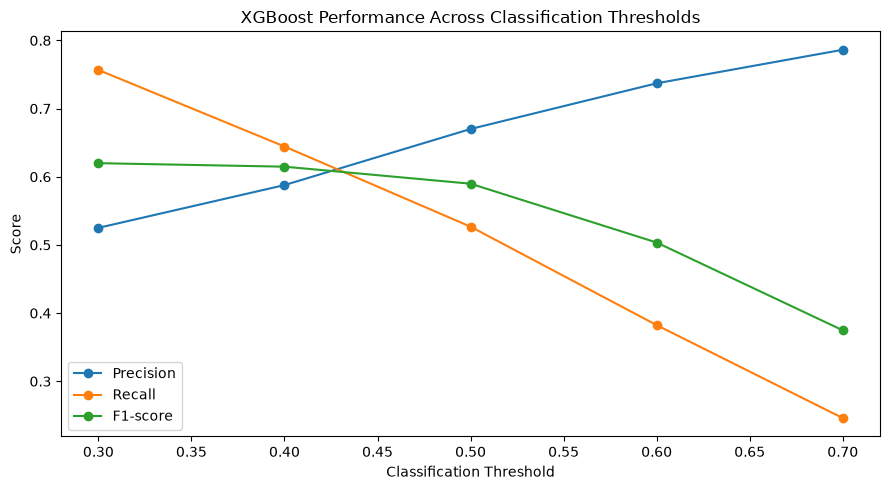

In [52]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1"],
    marker="o",
    label="F1-score"
)

plt.title("XGBoost Performance Across Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(images_folder, "threshold_analysis.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Lowering the classification threshold increases the number of customers classified as potential churners.

This generally increases recall because more actual churners are identified, but it also reduces precision because more non-churning customers are classified as potential churners.

Increasing the threshold has the opposite effect: the model becomes more selective, increasing precision while reducing recall.

The appropriate threshold should therefore depend on the business cost of missing a customer who may churn, the cost of contacting customers unnecessarily, and the capacity of the retention team.

## Model Interpretation

Model performance alone does not explain which customer characteristics contribute most strongly to the predictions.

Model interpretation was therefore performed using three complementary approaches:

1. Logistic Regression coefficients
2. XGBoost feature importance
3. Permutation feature importance

These methods provide different perspectives on the information used by the models.

### Logistic Regression Coefficients

Logistic Regression coefficients were examined to understand the direction of association between the encoded features and the model's predicted probability of churn.

Positive coefficients indicate an association with higher predicted churn probability, while negative coefficients indicate an association with lower predicted churn probability, holding the other model features constant.

These coefficients represent model associations rather than causal effects.

In [53]:
log_pipeline = pipelines["Logistic Regression"]

log_pipeline.fit(X_train, y_train)

log_preprocessor = log_pipeline.named_steps["preprocessor"]
log_model_fitted = log_pipeline.named_steps["model"]

feature_names = log_preprocessor.get_feature_names_out()

coefficients = log_model_fitted.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df_sorted = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df_sorted

,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.634195
36,cat__Contract_Month-to-month,0.582883
3,num__TotalCharges,0.536253
35,cat__StreamingMovies_Yes,0.200938
32,cat__StreamingTV_Yes,0.200481
43,cat__PaymentMethod_Electronic check,0.197867
18,cat__OnlineSecurity_No,0.156279
27,cat__TechSupport_No,0.131503
14,cat__MultipleLines_Yes,0.104649
0,num__SeniorCitizen,0.053449


In [54]:
coef_df_sorted.head(10)

,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.634195
36,cat__Contract_Month-to-month,0.582883
3,num__TotalCharges,0.536253
35,cat__StreamingMovies_Yes,0.200938
32,cat__StreamingTV_Yes,0.200481
43,cat__PaymentMethod_Electronic check,0.197867
18,cat__OnlineSecurity_No,0.156279
27,cat__TechSupport_No,0.131503
14,cat__MultipleLines_Yes,0.104649
0,num__SeniorCitizen,0.053449


In [55]:
coef_df_sorted.tail(10)

,Feature,Coefficient
19,cat__OnlineSecurity_No internet service,-0.300104
17,cat__InternetService_No,-0.300104
31,cat__StreamingTV_No internet service,-0.300104
25,cat__DeviceProtection_No internet service,-0.300104
22,cat__OnlineBackup_No internet service,-0.300104
39,cat__PaperlessBilling_No,-0.343227
2,num__MonthlyCharges,-0.591863
15,cat__InternetService_DSL,-0.648646
38,cat__Contract_Two year,-0.776594
1,num__tenure,-1.257539


### XGBoost Feature Importance

XGBoost's built-in feature importance was examined to identify encoded features that contributed to the model's predictions.

Because categorical variables were one-hot encoded, a single original variable may be represented by several encoded features. Therefore, individual encoded features should not automatically be interpreted as the complete importance of their original variable.

In [56]:
xgb_pipeline = pipelines["XGBoost"]

xgb_pipeline.fit(X_train, y_train)

xgb_preprocessor = xgb_pipeline.named_steps["preprocessor"]
xgb_model_fitted = xgb_pipeline.named_steps["model"]

xgb_feature_names = xgb_preprocessor.get_feature_names_out()

xgb_importance = xgb_model_fitted.feature_importances_

xgb_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_importance
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance_df

,Feature,Importance
36,cat__Contract_Month-to-month,0.510763
16,cat__InternetService_Fiber optic,0.144861
27,cat__TechSupport_No,0.037118
18,cat__OnlineSecurity_No,0.036082
15,cat__InternetService_DSL,0.024716
35,cat__StreamingMovies_Yes,0.022188
1,num__tenure,0.017539
37,cat__Contract_One year,0.016139
38,cat__Contract_Two year,0.015903
43,cat__PaymentMethod_Electronic check,0.013742


In [57]:
xgb_importance_df.head(10)

,Feature,Importance
36,cat__Contract_Month-to-month,0.510763
16,cat__InternetService_Fiber optic,0.144861
27,cat__TechSupport_No,0.037118
18,cat__OnlineSecurity_No,0.036082
15,cat__InternetService_DSL,0.024716
35,cat__StreamingMovies_Yes,0.022188
1,num__tenure,0.017539
37,cat__Contract_One year,0.016139
38,cat__Contract_Two year,0.015903
43,cat__PaymentMethod_Electronic check,0.013742


### Permutation Importance

Permutation importance was used to evaluate how much model performance changed when individual original features were randomly shuffled.

Unlike the built-in XGBoost importance, permutation importance is calculated at the original feature level. This makes it easier to interpret the importance of variables such as Contract, tenure, InternetService, and MonthlyCharges.

In [58]:
perm_result = permutation_importance(
    xgb_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
)

perm_df

,Feature,Importance_Mean,Importance_Std
14,Contract,0.091813,0.006020
4,tenure,0.060723,0.003377
7,InternetService,0.009222,0.003122
8,OnlineSecurity,0.006699,0.001335
17,MonthlyCharges,0.006108,0.003661
11,TechSupport,0.005072,0.001951
18,TotalCharges,0.004946,0.002261
15,PaperlessBilling,0.002686,0.001824
16,PaymentMethod,0.002207,0.001078
6,MultipleLines,0.002136,0.001711


In [59]:
perm_df.head(10)

,Feature,Importance_Mean,Importance_Std
14,Contract,0.091813,0.006020
4,tenure,0.060723,0.003377
7,InternetService,0.009222,0.003122
8,OnlineSecurity,0.006699,0.001335
17,MonthlyCharges,0.006108,0.003661
11,TechSupport,0.005072,0.001951
18,TotalCharges,0.004946,0.002261
15,PaperlessBilling,0.002686,0.001824
16,PaymentMethod,0.002207,0.001078
6,MultipleLines,0.002136,0.001711


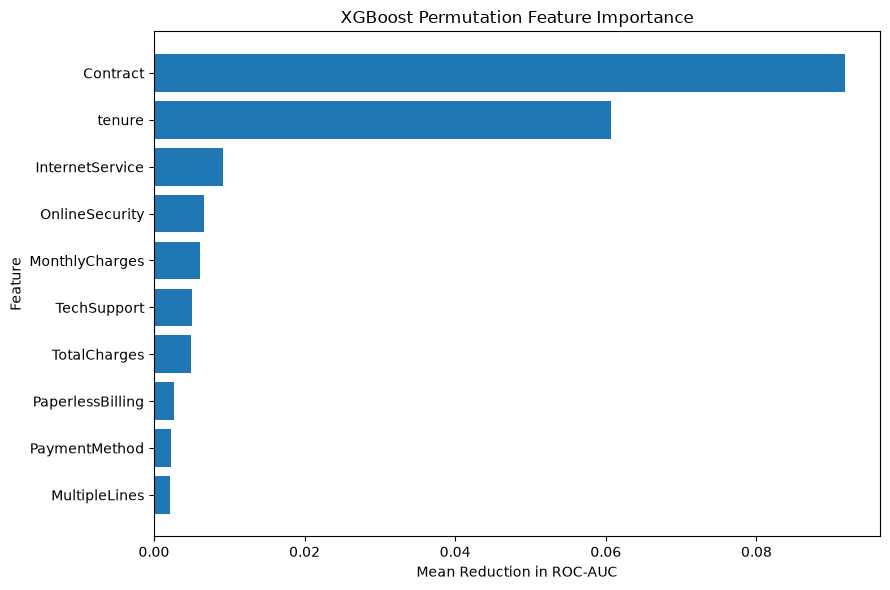

In [60]:
top_perm = perm_df.head(10).sort_values(
    "Importance_Mean",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance_Mean"]
)

plt.title("XGBoost Permutation Feature Importance")
plt.xlabel("Mean Reduction in ROC-AUC")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(images_folder, "permutation_importance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The strongest original features identified by permutation importance were Contract and tenure, followed by InternetService, OnlineSecurity, MonthlyCharges, TechSupport, and TotalCharges.

Contract and tenure showed substantially larger mean importance values than most other original features.

Features with near-zero or slightly negative permutation importance should not automatically be interpreted as harmful features. Small negative values can occur because of sampling variation and correlations between predictors.

These results indicate predictive importance within the model, not causation.

## Business Insights

The exploratory analysis and machine learning results identified several patterns associated with customer churn.

### Contract Type

Contract type was consistently one of the strongest variables associated with churn.

Month-to-month customers showed substantially higher observed churn than customers on longer-term contracts.

Contract was also the strongest original feature according to permutation importance.

### Customer Tenure

Customers with shorter tenure showed higher observed churn than customers who had remained with the company for longer periods.

Tenure was also one of the strongest features identified by permutation importance.

This suggests that the early customer lifecycle is an important period for retention analysis.

### Internet Service

Internet service type showed different observed churn patterns across customer groups.

Fiber-optic customers showed relatively high churn in the dataset, making this segment worthy of further investigation.

This relationship should be interpreted as an association rather than evidence that the type of internet service itself causes churn.

### Payment Method

Electronic-check customers showed relatively high observed churn compared with several other payment-method groups.

This pattern should be investigated alongside other customer characteristics such as contract type, tenure, and service usage.

### Support and Security Services

OnlineSecurity and TechSupport appeared among the more important variables in the model interpretation analysis.

Customers without these services showed different churn patterns in the exploratory analysis.

These variables may therefore be useful when developing customer-risk segments.

### Overall Model Findings

Contract and tenure were the strongest original features identified through permutation importance.

The model evaluation also showed that Logistic Regression, Gradient Boosting, and XGBoost produced broadly similar ROC-AUC performance, while the Decision Tree showed substantially weaker performance and a large training-test accuracy gap.

## Business Recommendations

Based on the observed patterns and model interpretation, the following actions could be considered as part of a customer-retention strategy.

### Strengthen Early-Tenure Retention

Develop a structured onboarding and early-retention program for new customers, particularly during the first several months.

Possible actions include:

- Welcome and onboarding communication
- Early satisfaction checks
- Proactive technical support
- Education about available services
- Targeted retention interventions where appropriate

### Monitor Month-to-Month Customers

Month-to-month customers represent an important segment for churn monitoring.

The business could consider:

- Targeted engagement
- Loyalty incentives
- Personalized service offers
- Satisfaction surveys
- Contract-transition opportunities

Any intervention should be evaluated using appropriate measurement methods before being scaled.

### Investigate Fiber-Optic Customer Experience

The analysis identified relatively high observed churn among fiber-optic customers.

The business should investigate possible explanations, including:

- Service reliability
- Installation experience
- Pricing
- Technical support
- Network performance
- Customer expectations

The observed relationship should not be interpreted as proof that fiber-optic service causes churn.

### Investigate Electronic-Check Customers

Customers using electronic checks showed relatively high observed churn.

The company could investigate whether this segment differs systematically in contract type, tenure, charges, or service usage.

### Use an Appropriate Prediction Threshold

The threshold analysis showed that lowering the classification threshold increases recall while reducing precision.

Therefore, the threshold used in a production retention system should be selected according to:

- Cost of contacting customers
- Cost of losing a customer
- Retention-team capacity
- Expected effectiveness of retention interventions

The threshold should ideally be selected using validation data or out-of-fold predictions before final deployment.

## Limitations

Several limitations should be considered when interpreting the results.

### Observational Data

The dataset is observational. Therefore, relationships identified in the analysis should be interpreted as associations rather than causal effects.

For example, higher observed churn among fiber-optic customers does not by itself demonstrate that fiber-optic service causes churn.

### Model Performance

The models achieved useful discriminatory performance, but none of the models classified every customer correctly.

Some customers will therefore be incorrectly classified.

### Class Imbalance

The dataset contains more non-churn customers than churn customers.

Accuracy alone is therefore insufficient for evaluating the models.

Precision, recall, F1-score, ROC-AUC, and confusion matrices were also examined.

### Threshold Selection

The classification threshold affects the balance between precision and recall.

A production threshold should therefore be selected according to business costs and operational capacity rather than accuracy alone.

### Feature Representation

Categorical variables were one-hot encoded for modeling.

Consequently, some original variables are represented by multiple encoded features. This should be considered when interpreting built-in feature importance and Logistic Regression coefficients.

### Generalization

The findings are based on this dataset and may not generalize directly to other telecommunications companies, markets, or customer populations.

External validation on new customer data would be required before operational deployment.

## Conclusion

This project analyzed customer churn using an end-to-end data analytics and machine learning workflow.

The exploratory analysis identified substantial differences in observed churn across contract type, tenure, internet service, payment method, and several service-related variables.

Five classification models were developed and evaluated using multiple performance metrics, including accuracy, precision, recall, F1-score, and ROC-AUC.

Cross-validation showed that Logistic Regression, Gradient Boosting, and XGBoost produced broadly similar discriminatory performance on the available data, while the Decision Tree showed substantially weaker performance and a large training-test accuracy gap.

The threshold analysis demonstrated that changing the classification threshold can materially alter the balance between precision and recall. This is important when considering how a churn model could support customer-retention activities.

Model interpretation provided additional insight into the variables used by the models. Contract and tenure were the strongest original features according to permutation importance.

Overall, the project demonstrates an end-to-end approach to using data analysis and machine learning to investigate customer churn, evaluate predictive models, interpret model behavior, and translate analytical findings into potential business actions.